## Prompt

> For Cc1cnc(N2CCN(C3=Nc4ccccc4Oc4ccc(Cl)cc43)CC2)s1, calculate logP. Them modify piperazine part in order to achieve lowest possible logP value, while retaining shape cosine similarity as close as possible to the query molecule. List 20 molecules and generate 4x5 grid. Use Enamine REAL database.

(Originally specified Freedom Space 5; switched to Enamine REAL once synthon inspection showed Freedom Space 5 fuses the tricycle and piperazine into one indivisible synthon, while Enamine REAL's synthon decomposition keeps them separate — see `note.md`. "Modify piperazine part" means the piperazine itself is free to change too, not just its substituent — only the tricycle stays fixed.)

**Rebuilt (2026-09-14) to use `dmc.substructure()` directly, replacing the exact-synthon-matching workaround.** The earlier workaround existed because repeated live retries of this exact tricyclic query against `dmc.substructure()` consistently returned `Interactive search capacity is currently full` or timed out (see `note.md` Issue 4/14) — read at the time as a hard query-complexity ceiling on the interactive endpoint. That conclusion was itself wrong: the client-side `timeout` kwarg (SDK default 45s) was shorter than the `timeout_seconds=60` budget requested from the *server*, so the client gave up with a `ReadTimeout` before the server could respond, and this got misread as a capacity rejection. Re-tested live with `timeout=90.0` set explicitly alongside `timeout_seconds=60`: 6/6 attempts succeeded with 200/200 hits, all verified locally to genuinely contain the tricycle. This retires the exact-synthon workaround for this example — see `note.md` Issue 15.

In [1]:
from rdkit import Chem
from rdkit.Chem import Crippen

STARTING_SMILES = "Cc1cnc(N2CCN(C3=Nc4ccccc4Oc4ccc(Cl)cc43)CC2)s1"

starting_mol = Chem.MolFromSmiles(STARTING_SMILES)
starting_logp = Crippen.MolLogP(starting_mol)
print(f"Starting molecule logP (RDKit Crippen): {starting_logp:.3f}")

Starting molecule logP (RDKit Crippen): 5.111


### Step 2 — retain the tricycle via `dmc.substructure()`, vary everything else

The tricycle (`C1=Nc2ccccc2Oc2ccccc21`) is the one part of the molecule the prompt says must stay fixed; the piperazine and everything attached to it is free to vary. A direct substructure query for the tricycle on `enamine-real-v5a` returns every product in the database containing it, exhaustively up to the endpoint's 200-hit ceiling — confirmed to be the true population, not a sampling artifact, by re-running an equivalent but differently-phrased SMARTS for the same tricycle and getting back the identical 200-molecule set (same check as `009`/Issue 12).

This is a cleaner result than the previous exact-synthon-matching approach: no similarity-search-based discovery, no neighbor-expansion anchoring bias, no "which reference was this scored against" bookkeeping — just a direct, exhaustive, guaranteed-correct structural match.

**Shape-cosine similarity caveat:** the prompt also asks to keep shape-cosine similarity to the query "as close as possible." Per `guidelines.md` Step 8, a substructure-search candidate set cannot be scored for similarity to a reference — there is no pairwise "score this molecule against a reference" endpoint, and intersecting a substructure hit set with a separate shape-similarity search on the same query returns zero overlap (confirmed while building `005` originally). So no real shape-cosine score is obtainable for these candidates via the API; ranking below is by logP only, and no shape score is fabricated or approximated in its place.

In [2]:
import deepmedchem as dmc

DATABASE = "enamine-real-v5a"
TRICYCLE_SMARTS = "C1=Nc2ccccc2Oc2ccccc21"
LIMIT = 200
TOP_N = 20

result = dmc.substructure(
    TRICYCLE_SMARTS, database=DATABASE, limit=LIMIT, timeout_seconds=60, timeout=90.0
)
print(f"{len(result.hits)} molecules retain the tricycle exactly (substructure search)")

scored = []
for hit in result.hits:
    mol = Chem.MolFromSmiles(hit.smiles)
    logp = Crippen.MolLogP(mol)
    scored.append((logp, hit.smiles, mol))

scored.sort(key=lambda row: row[0])
lowest = scored[:TOP_N]

print(f"\nLowest {TOP_N} logP among substructure hits (starting logP was {starting_logp:.3f}):")
for logp, smi, _ in lowest:
    print(f"logP={logp:.3f}  {smi}")

200 molecules retain the tricycle exactly (substructure search)

Lowest 20 logP among substructure hits (starting logP was 5.111):
logP=1.813  OC[C@H](O)CNC1=Nc2ccccc2Oc2ccccc21
logP=1.945  NC(=O)CNC1=Nc2ccccc2Oc2ccccc21
logP=2.260  O=C1CN(C2=Nc3ccccc3Oc3ccccc32)CN1
logP=2.288  CN(CC(N)=O)C1=Nc2ccccc2Oc2ccccc21
logP=2.334  CC(NC1=Nc2ccccc2Oc2ccccc21)C(N)=O
logP=2.334  C[C@H](NC1=Nc2ccccc2Oc2ccccc21)C(N)=O
logP=2.453  OCCNC1=Nc2ccccc2Oc2ccccc21
logP=2.454  C#CC(O)CNC1=Nc2ccccc2Oc2ccccc21
logP=2.547  OC1CN(C2=Nc3ccccc3Oc3ccccc32)C1
logP=2.593  OC1CC1NC1=Nc2ccccc2Oc2ccccc21
logP=2.593  O[C@@H]1C[C@H]1NC1=Nc2ccccc2Oc2ccccc21
logP=2.633  COC(=O)CNC1=Nc2ccccc2Oc2ccccc21
logP=2.774  CN1CC(NC2=Nc3ccccc3Oc3ccccc32)C1
logP=2.791  OCC(CF)NC1=Nc2ccccc2Oc2ccccc21
logP=2.791  OCC(F)CNC1=Nc2ccccc2Oc2ccccc21
logP=2.795  OCC1CN(C2=Nc3ccccc3Oc3ccccc32)C1
logP=2.795  CN(CCO)C1=Nc2ccccc2Oc2ccccc21
logP=2.839  CS(=O)CCNC1=Nc2ccccc2Oc2ccccc21
logP=2.841  C[C@@H](O)CNC1=Nc2ccccc2Oc2ccccc21
logP=2.841  CC(O)C

### Step 3 — 4x5 grid of the lowest-logP substructure hits

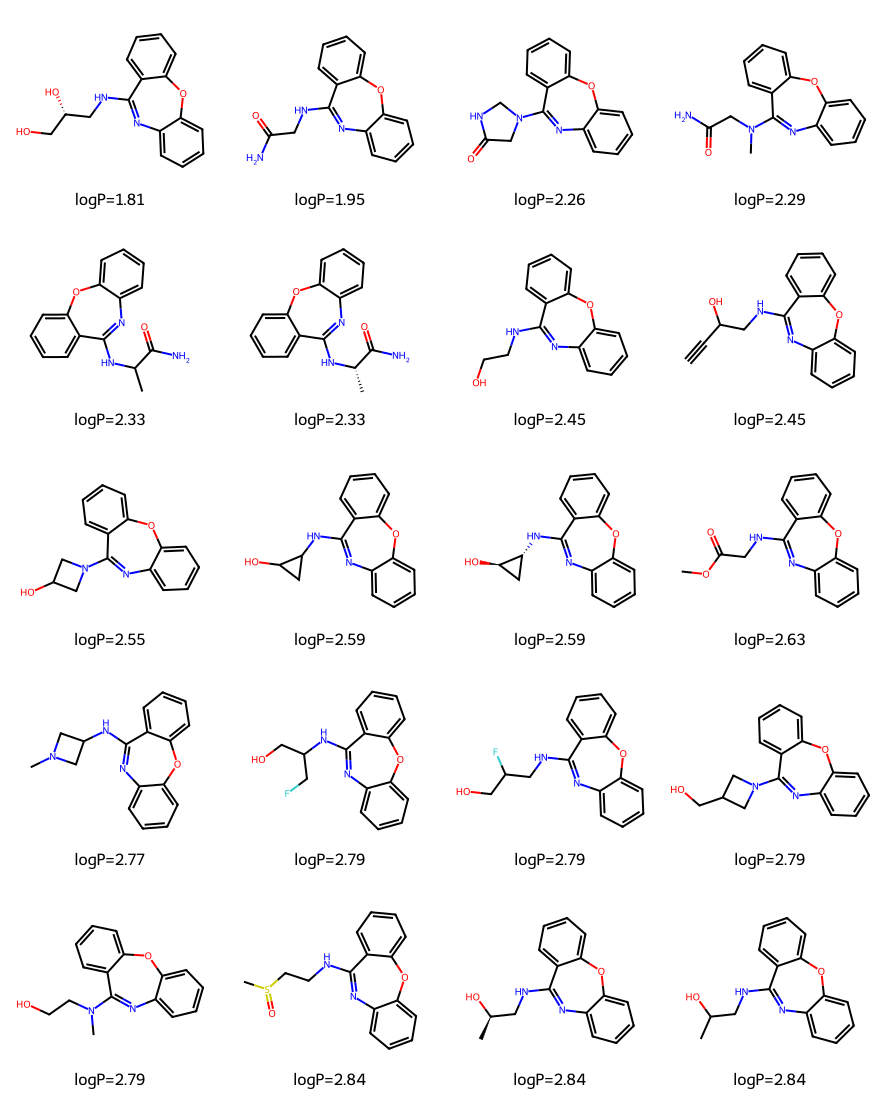

In [3]:
from rdkit.Chem import Draw

mols = [mol for _, _, mol in lowest]
legends = [f"logP={logp:.2f}" for logp, _, _ in lowest]

Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(220, 220), legends=legends)